In [3]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

--2026-05-19 16:39:17--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-19 16:39:17--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2026-05-19 16:39:17 (4.19 MB/s) - ‘thinkdsp.py’ saved [48554/48554]

--2026-05-19 16:39:17--  https://github.com/AllenDo

# 3.1

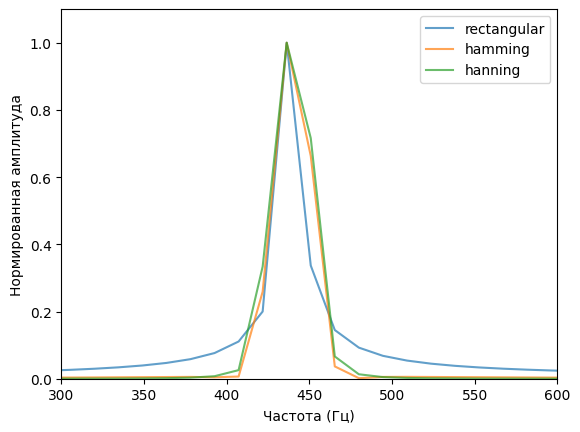

<Figure size 800x600 with 0 Axes>

In [10]:
import numpy as np
import thinkdsp
import thinkplot
from scipy import signal as scipy_signal

# Синусоидальный сигнал 440 Гц, длительность 30.25 периодов (не кратно)
sin_sig = thinkdsp.SinSignal(freq=440)
duration = sin_sig.period * 30.25
wave = sin_sig.make_wave(duration=duration, framerate=11025)

# Функция для применения окна и построения спектра
def test_window(window_func, win_name, **kwargs):
    w = wave.copy()
    N = len(w.ys)
    if win_name == 'kaiser':
        window = window_func(N, **kwargs)
    else:
        window = window_func(N)
    w.ys *= window
    spec = w.make_spectrum()
    spec.hs /= np.max(np.abs(spec.hs))
    spec.plot(label=win_name, alpha=0.7)

# Исходный сигнал без окна (прямоугольное окно)
test_window(np.ones, 'rectangular')

# Различные окна
test_window(np.hamming, 'hamming')
test_window(np.hanning, 'hanning')

thinkplot.config(xlabel='Частота (Гц)', ylabel='Нормированная амплитуда',
                 xlim=[300, 600], ylim=[0, 1.1])
thinkplot.show()

Окна Хэмминга и Ханна (один из NumPy) значительно снижают боковые лепестки по сравнению с прямоугольным окном

# 3.2

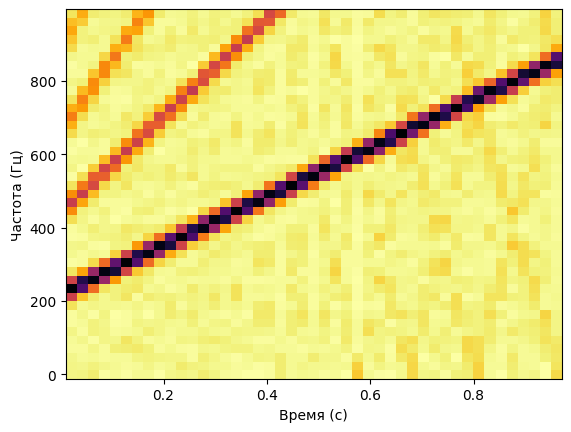

<Figure size 800x600 with 0 Axes>

In [18]:
class SawtoothChirp(thinkdsp.Chirp):
    def evaluate(self, ts):
        # вычисляем частоты на каждом интервале (линейный чирп)
        freqs = np.linspace(self.start, self.end, len(ts)-1)
        # используем _evaluate из Chirp, который генерирует фазу
        # и возвращает синусоиду
        dts = np.diff(ts)
        dphis = 2 * np.pi * freqs * dts
        phases = np.cumsum(dphis)
        phases = np.insert(phases, 0, 0)
        # пилообразный сигнал: linear ramp from -1 to 1
        # frac = (phases / (2pi)) % 1  ->  часть периода
        frac = (phases / (2*np.pi)) % 1.0
        ys = 2 * (frac - 0.5)   # от -1 до 1
        # масштабируем амплитуду
        ys = self.amp * ys
        return ys

signal = SawtoothChirp(start=220, end=880)
wave = signal.make_wave(duration=1, framerate=6000)

spectrogram = wave.make_spectrogram(seg_length=256)
spectrogram.plot(high=1000)
thinkplot.config(xlabel='Время (с)', ylabel='Частота (Гц)')
thinkplot.show()

# 3.3

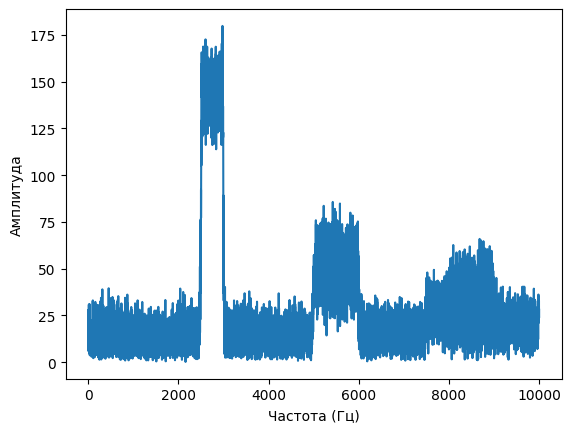

<Figure size 800x600 with 0 Axes>

In [24]:
signal = SawtoothChirp(start=2500, end=3000, amp=0.5)
wave = signal.make_wave(duration=1, framerate=20000)
spectrum = wave.make_spectrum()
spectrum.plot()
thinkplot.config(xlabel='Частота (Гц)', ylabel='Амплитуда')
thinkplot.show()

Видим "око Саурона" на основных частотах и её гармониках, а также гармоники выше 10 кГц отражаются и попадают в этот же диапазон

# 3.4

In [26]:
if not os.path.exists('72475__rockwehrmann__glissup02.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/72475__rockwehrmann__glissup02.wav

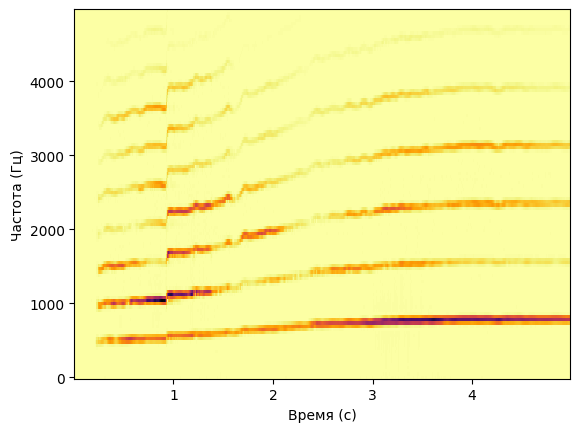

<Figure size 800x600 with 0 Axes>

In [27]:
wave = thinkdsp.read_wave('72475__rockwehrmann__glissup02.wav')

wave = wave.segment(start=0, duration=5)
# Строим спектрограмму с длиной сегмента 1024
spectrogram = wave.make_spectrogram(seg_length=1024)
spectrogram.plot(high=5000)
thinkplot.config(xlabel='Время (с)', ylabel='Частота (Гц)')
thinkplot.show()

Видно, как основная частота (и гармоники) плавно поднимаются вверх, образуя непрерывную "змейку"

# 3.5
Если кулиса двигается с постоянной скоростью, то частота меняется по формуле
f(t) = c/(L0 + vt)

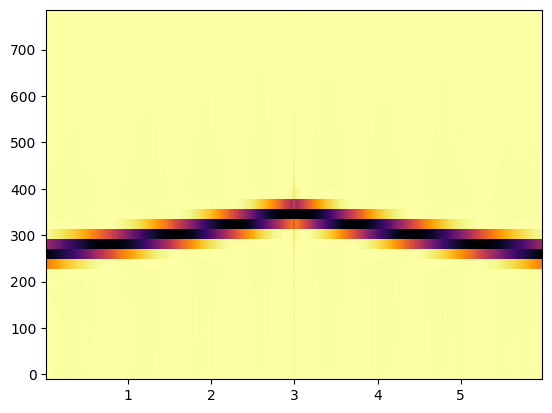

<Figure size 800x600 with 0 Axes>

In [39]:
class TromboneGliss(thinkdsp.Chirp):
    def __init__(self, start, end, duration, amp=1.0):
        self.start_freq = start
        self.end_freq = end
        self.duration = duration
        self.amp = amp
        # Вычисляем параметры гиперболы: f(t) = a / (b + t)
        # при t=0: f0 = a/b => a = f0*b
        # при t=duration: f1 = a/(b+duration)
        # из двух уравнений находим b и a
        # f1 = f0*b/(b+duration) => b = duration * f1 / (f0 - f1)
        # a = f0 * b
        self.b = duration * end / (start - end)
        self.a = start * self.b

    def evaluate(self, ts):
        # Вычисляем частоту в каждый момент времени
        freqs = self.a / (self.b + ts)
        dts = np.diff(ts)
        # берём частоты в середине интервалов
        freqs_mid = (freqs[:-1] + freqs[1:]) / 2
        dphis = 2 * np.pi * freqs_mid * dts
        phases = np.cumsum(dphis)
        phases = np.insert(phases, 0, 0)
        # Генерируем сигнал (просто синусоидальный, для тромбона)
        ys = self.amp * np.cos(phases)
        return ys

signal1 = TromboneGliss(start=262, end=349, duration=3)
wave1 = signal1.make_wave(framerate=44100, duration=signal1.duration)
signal2 = TromboneGliss(start=349, end=262, duration=3)
wave2 = signal2.make_wave(framerate=44100, duration=signal2.duration)

wave = wave1 | wave2

# Спектрограмма
spectrogram = wave.make_spectrogram(seg_length=2048)
spectrogram.plot(high=800)
thinkplot.show()

wave.make_audio()

# 3.6

In [43]:
if not os.path.exists('87778__marcgascon7__vocals.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/87778__marcgascon7__vocals.wav

In [44]:
wave = thinkdsp.read_wave('87778__marcgascon7__vocals.wav')
wave.make_audio()

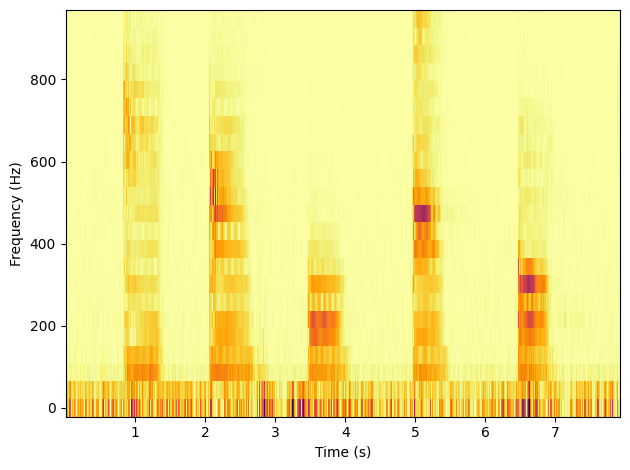

In [46]:
wave.make_spectrogram(1024).plot(high=1000)
thinkdsp.decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

In [ ]:
Да, можно различить. Например для "a" полосы повышенной энергии выше, чем для "u" и других гласных